In [1]:
import pandas as pd
import numpy as np

original_df = pd.read_excel('DMA DATASET.xlsx')

# creating a copy of the original dataframe to work with
df = original_df.copy()

### Summary of the Dataset:
This dataset is designed for skill gap analysis, focusing on evaluating the skill gap between students’ current skills and industry requirements. It provides insights into technical skills, soft skills, career interests, and challenges, helping in skill gap analysis to identify areas for improvement.

By leveraging this dataset, educators, recruiters, and researchers can conduct skill gap analysis to assess students’ job readiness and tailor training programs accordingly. It serves as a valuable resource for identifying skill deficiencies and skill gaps improving career guidance, and enhancing curriculum design through targeted skill gap analysis.

### Columns Descriptions:
* **Name** - Student's full name.
* **email_id** - Student's email address.
* **Year** - The academic year the student is currently in (e.g., 1st Year, 2nd Year, etc.).
* **Current Course** - The course the student is currently pursuing (e.g., B.Tech CSE, MBA, etc.).
* **Technical Skills** - List of technical skills possessed by the student (e.g., Python, Data Analysis, Cloud Computing).
* **Programming Languages** - Programming languages known by the student (e.g., Python, Java, C++).
* **Rating** - Self-assessed rating of technical skills on a scale of 1 to 5.
* **Soft Skills** - List of soft skills (e.g., Communication, Leadership, Teamwork).
* **Rating** - Self-assessed rating of soft skills on a scale of 1 to 5.
* **Projects** - Indicates whether the student has worked on any projects (Yes/No).
* **Career Interest** - The student's preferred career path (e.g., Data Scientist, Software Engineer).
* **Challenges** - Challenges faced while applying for jobs/internships (e.g., Lack of experience, Resume building issues).

In [2]:
df.head()

,Name,email_id,Year,Current Course,Technical Skills,Programming Languages,Rating,Soft Skills,Rating.1,Projects,Career Interest,Challenges,Support required,Unnamed: 13,Method
0,Iorgo Hakonsen,ihakonsen0@instagram.com,2nd,MBA,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",1,Yes,Data Scientist,Interview anxiety,Mentorship programs,NaN,College curriculum
1,Emmery Duffyn,eduffyn1@dailymotion.com,Final,BBA,"SQL, Machine Learning","R, Go",3,"Leadership, Communication, Problem-Solving",4,No,AI Engineer,No networking opportunities,Technical skill training,NaN,College curriculum
2,Susanetta Wards,swards2@digg.com,2nd,B.Sc Data Science,"Cybersecurity, Java",JavaScript,4,"Leadership, Time Management, Problem-Solving",1,No,Data Scientist,Interview anxiety,Technical skill training,NaN,Self-study
3,Amanda Gussin,agussin3@webs.com,2nd,M.Tech AI,"Blockchain, Python, SQL","Python, C#",3,"Adaptability, Teamwork, Leadership",4,No,Cybersecurity Expert,Limited guidance,Resume workshops,NaN,College curriculum
4,Carlina Beaven,cbeaven4@timesonline.co.uk,1st,B.Tech IT,"Blockchain, Machine Learning, Python","Java, Go",4,"Teamwork, Adaptability, Problem-Solving",3,Yes,Cybersecurity Expert,No networking opportunities,Internship opportunities,NaN,Online


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        500 non-null    object 
 1   email_id                    500 non-null    object 
 2   Year                        500 non-null    object 
 3   Current Course              500 non-null    object 
 4   Technical Skills            500 non-null    object 
 5        Programming Languages  500 non-null    object 
 6   Rating                      500 non-null    int64  
 7   Soft Skills                 500 non-null    object 
 8   Rating.1                    500 non-null    int64  
 9    Projects                   500 non-null    object 
 10  Career Interest             500 non-null    object 
 11  Challenges                  500 non-null    object 
 12  Support required            500 non-null    object 
 13  Unnamed: 13                 0 non-n

In [4]:
df.sample(5)

,Name,email_id,Year,Current Course,Technical Skills,Programming Languages,Rating,Soft Skills,Rating.1,Projects,Career Interest,Challenges,Support required,Unnamed: 13,Method
378,Devinne Stidson,dstidsonai@free.fr,1st Year,M.Tech AI,"Machine Learning, Blockchain, Java","C#, Go, Java",3,"Communication, Teamwork, Problem-Solving",3,No,Data Scientist,Interview anxiety,Resume workshops,NaN,Self-study
432,Melisandra Kenelin,mkenelinc0@shinystat.com,1st Year,M.Tech AI,"Machine Learning, Java, SQL, Data Analysis",C#,5,"Teamwork, Problem-Solving, Leadership",1,Yes,Cloud Architect,Interview anxiety,Mentorship programs,NaN,Online
100,Wanids Shaxby,wshaxby2s@phoca.cz,3rd Year,MBA,"Python, Cybersecurity, Data Analysis","R, C#, Java",2,"Problem-Solving, Time Management, Communication",5,Yes,Data Scientist,No networking opportunities,Resume workshops,NaN,Bootcamp
52,Gertrud Syphas,gsyphas1g@twitpic.com,2nd Year,M.Tech AI,"Cybersecurity, SQL, Blockchain","JavaScript, Python",3,"Problem-Solving, Leadership, Time Management",5,Yes,Cybersecurity Expert,Interview anxiety,Mentorship programs,NaN,Bootcamp
342,Dewain Oxburgh,doxburgh9i@ifeng.com,3rd Year,B.Tech IT,"Cloud Computing, Cybersecurity, Blockchain",R,2,"Leadership, Problem-Solving",2,No,AI Engineer,No networking opportunities,Resume workshops,NaN,Bootcamp


In [5]:
# making all column names lowercase and replacing spaces with underscores for easier access
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [6]:
def to_lowercase(df: pd.DataFrame) -> pd.DataFrame:
    """Converts all string columns in the DataFrame to lowercase and strips leading/trailing whitespace."""
    for col in df.columns:
        if df[col].dtype == 'str':
            df[col] = df[col].str.strip().str.lower()
    return df
df = to_lowercase(df)

In [7]:
# check the null values in the dataset
df.isnull().sum()

name                       0
email_id                   0
year                       0
current_course             0
technical_skills           0
programming_languages      0
rating                     0
soft_skills                0
rating.1                   0
projects                   0
career_interest            0
challenges                 0
support_required           0
unnamed:_13              500
method                     0
dtype: int64

In [8]:
# dropping the unnamed: 13 column as it contains no data
df.drop(columns=['unnamed:_13'], inplace=True)

In [9]:
# drop the duplicate 'rating' column which is for soft skills as we already have a 'rating' column for technical skills
df.drop(columns=['rating.1'],inplace=True)

In [10]:
# rename the 'email_id' column to 'email' for better clarity
df.rename(columns={'email_id': 'email'}, inplace=True)

In [11]:
df['name'].sample(4)

224             Alayne Drew
487            Cele Frodsam
379        Robbyn Spilsbury
149    Maribelle Pinnington
Name: name, dtype: object

In [12]:
df['year'].sample(2)

243    Final Year
334      2nd Year
Name: year, dtype: object

In [13]:
# converting the 'year' column to a numeric format for easier analysis and mapping the values to their corresponding numeric representations
year_dict ={
    "1st year": 1,
    "2nd year": 2,
    "3rd year": 3,
    "final year": 4
}
df['year'] = df['year'].str.strip().str.lower().map(year_dict)

In [14]:
df['current_course'].value_counts().sort_values(ascending=False)

current_course
MBA                  93
M.Tech AI            92
BBA                  83
B.Sc Data Science    80
B.Tech IT            77
B.Tech CSE           75
Name: count, dtype: int64

In [15]:
# mapping the current course values to their full forms for better readability and analysis
course_full_forms = {
    "mba": "Master of Business Administration",
    "m.tech ai": "Master of Technology in Artificial Intelligence",
    "bba": "Bachelor of Business Administration",
    "b.sc data science": "Bachelor of Science in Data Science",
    "b.tech it": "Bachelor of Technology in Information Technology",
    "b.tech cse": "Bachelor of Technology in Computer Science and Engineering"
}
df['current_course'] = df['current_course'].str.strip().str.lower().map(course_full_forms)

In [16]:
df.technical_skills.value_counts().sort_values(ascending=False)

technical_skills
Data Analysis, Cybersecurity                                    9
Data Analysis, Python                                           6
Blockchain, Java                                                6
Machine Learning, Cybersecurity                                 6
SQL, Java                                                       6
                                                               ..
Cybersecurity, SQL, Blockchain                                  1
Python, Cybersecurity, Blockchain, Machine Learning             1
Machine Learning, Java, Cloud Computing                         1
Machine Learning, Blockchain, Data Analysis, Cloud Computing    1
Machine Learning, Cybersecurity, Python, Data Analysis          1
Name: count, Length: 336, dtype: int64

In [17]:
df['programming_languages_list'] = df['programming_languages'].str.split(', ')
df.explode('programming_languages_list')

,name,email,year,current_course,technical_skills,programming_languages,rating,soft_skills,projects,career_interest,challenges,support_required,method,programming_languages_list
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,Python
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,R
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,C#
1,Emmery Duffyn,eduffyn1@dailymotion.com,NaN,Bachelor of Business Administration,"SQL, Machine Learning","R, Go",3,"Leadership, Communication, Problem-Solving",No,AI Engineer,No networking opportunities,Technical skill training,College curriculum,R
1,Emmery Duffyn,eduffyn1@dailymotion.com,NaN,Bachelor of Business Administration,"SQL, Machine Learning","R, Go",3,"Leadership, Communication, Problem-Solving",No,AI Engineer,No networking opportunities,Technical skill training,College curriculum,Go
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,Desdemona Dalziell,ddalzielldu@squidoo.com,1.0,Master of Business Administration,"Machine Learning, Python, Data Analysis","C#, Java, Python",1,"Communication, Problem-Solving, Adaptability",No,Data Scientist,Limited guidance,Mentorship programs,Bootcamp,C#
498,Desdemona Dalziell,ddalzielldu@squidoo.com,1.0,Master of Business Administration,"Machine Learning, Python, Data Analysis","C#, Java, Python",1,"Communication, Problem-Solving, Adaptability",No,Data Scientist,Limited guidance,Mentorship programs,Bootcamp,Java
498,Desdemona Dalziell,ddalzielldu@squidoo.com,1.0,Master of Business Administration,"Machine Learning, Python, Data Analysis","C#, Java, Python",1,"Communication, Problem-Solving, Adaptability",No,Data Scientist,Limited guidance,Mentorship programs,Bootcamp,Python
499,Kiel Meysham,kmeyshamdv@purevolume.com,4.0,Bachelor of Science in Data Science,"Cloud Computing, Java","Java, C++",1,"Communication, Leadership, Problem-Solving",No,Cloud Architect,Difficulty in resume building,Resume workshops,Bootcamp,Java


In [18]:
df['soft_skills_list'] = df['soft_skills'].str.split(', ')


In [19]:
skills_df = df.explode('soft_skills_list')

In [20]:
skills_df

,name,email,year,current_course,technical_skills,programming_languages,rating,soft_skills,projects,career_interest,challenges,support_required,method,programming_languages_list,soft_skills_list
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,"[Python, R, C#]",Communication
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,"[Python, R, C#]",Adaptability
0,Iorgo Hakonsen,ihakonsen0@instagram.com,NaN,Master of Business Administration,"Cybersecurity, Blockchain","Python, R, C#",2,"Communication, Adaptability, Problem-Solving",Yes,Data Scientist,Interview anxiety,Mentorship programs,College curriculum,"[Python, R, C#]",Problem-Solving
1,Emmery Duffyn,eduffyn1@dailymotion.com,NaN,Bachelor of Business Administration,"SQL, Machine Learning","R, Go",3,"Leadership, Communication, Problem-Solving",No,AI Engineer,No networking opportunities,Technical skill training,College curriculum,"[R, Go]",Leadership
1,Emmery Duffyn,eduffyn1@dailymotion.com,NaN,Bachelor of Business Administration,"SQL, Machine Learning","R, Go",3,"Leadership, Communication, Problem-Solving",No,AI Engineer,No networking opportunities,Technical skill training,College curriculum,"[R, Go]",Communication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,Desdemona Dalziell,ddalzielldu@squidoo.com,1.0,Master of Business Administration,"Machine Learning, Python, Data Analysis","C#, Java, Python",1,"Communication, Problem-Solving, Adaptability",No,Data Scientist,Limited guidance,Mentorship programs,Bootcamp,"[C#, Java, Python]",Problem-Solving
498,Desdemona Dalziell,ddalzielldu@squidoo.com,1.0,Master of Business Administration,"Machine Learning, Python, Data Analysis","C#, Java, Python",1,"Communication, Problem-Solving, Adaptability",No,Data Scientist,Limited guidance,Mentorship programs,Bootcamp,"[C#, Java, Python]",Adaptability
499,Kiel Meysham,kmeyshamdv@purevolume.com,4.0,Bachelor of Science in Data Science,"Cloud Computing, Java","Java, C++",1,"Communication, Leadership, Problem-Solving",No,Cloud Architect,Difficulty in resume building,Resume workshops,Bootcamp,"[Java, C++]",Communication
499,Kiel Meysham,kmeyshamdv@purevolume.com,4.0,Bachelor of Science in Data Science,"Cloud Computing, Java","Java, C++",1,"Communication, Leadership, Problem-Solving",No,Cloud Architect,Difficulty in resume building,Resume workshops,Bootcamp,"[Java, C++]",Leadership


In [21]:
df['projects'].value_counts().sort_values(ascending=False)

projects
No     254
Yes    246
Name: count, dtype: int64

In [22]:
df.career_interest.value_counts().sort_values(ascending=False)

career_interest
Cloud Architect         98
Software Developer      92
Data Scientist          85
Cybersecurity Expert    78
Business Analyst        77
AI Engineer             70
Name: count, dtype: int64

In [23]:
df['challenges'].value_counts().sort_values(ascending=False)

challenges
No networking opportunities      112
Interview anxiety                104
Lack of experience               102
Difficulty in resume building     93
Limited guidance                  89
Name: count, dtype: int64

In [24]:
df.support_required.value_counts().sort_values(ascending=False)

support_required
Resume workshops            143
Mentorship programs         133
Technical skill training    114
Internship opportunities    110
Name: count, dtype: int64

In [25]:
df.method.value_counts().sort_values(ascending=False)

method
College curriculum    139
Self-study            136
Online                114
Bootcamp              111
Name: count, dtype: int64

In [26]:
df.drop(columns=['programming_languages_list', 'soft_skills_list'], inplace=True)

In [27]:
df.columns

Index(['name', 'email', 'year', 'current_course', 'technical_skills',
       'programming_languages', 'rating', 'soft_skills', 'projects',
       'career_interest', 'challenges', 'support_required', 'method'],
      dtype='object')

In [28]:
df.isnull().sum()

name                      0
email                     0
year                     11
current_course            0
technical_skills          0
programming_languages     0
rating                    0
soft_skills               0
projects                  0
career_interest           0
challenges                0
support_required          0
method                    0
dtype: int64

In [29]:
df['year'].isnull().sum()/len(df)*100

np.float64(2.1999999999999997)

In [30]:
df = df.dropna(subset=['year'])

In [31]:
df.isnull().sum()

name                     0
email                    0
year                     0
current_course           0
technical_skills         0
programming_languages    0
rating                   0
soft_skills              0
projects                 0
career_interest          0
challenges               0
support_required         0
method                   0
dtype: int64

In [32]:
df.to_csv('cleaned_data.csv', index=False)

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('cleaned_data.csv')


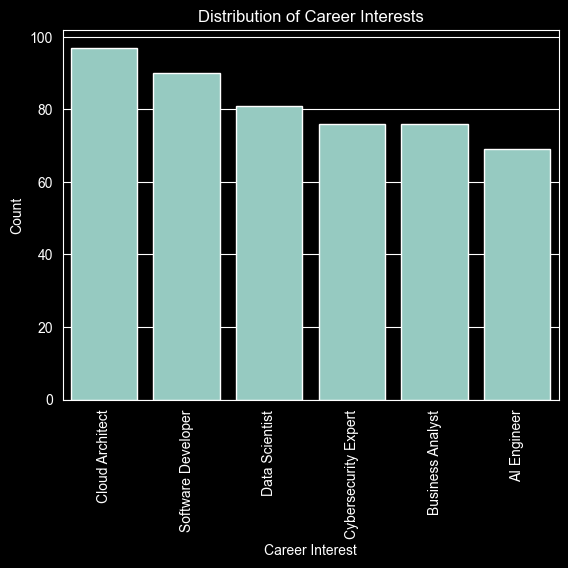

In [34]:
sns.countplot(data=df,x='career_interest',order=df['career_interest'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Career Interests')
plt.xlabel('Career Interest')
plt.ylabel('Count')
plt.show()

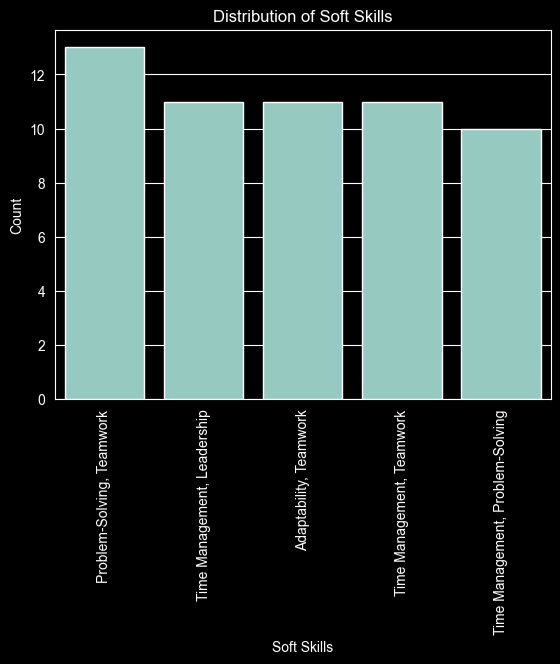

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x='soft_skills',
    order=df['soft_skills'].value_counts().sort_values(ascending=False).head().index
)

plt.xticks(rotation=90)
plt.title('Distribution of Soft Skills')
plt.xlabel('Soft Skills')
plt.ylabel('Count')
plt.show()

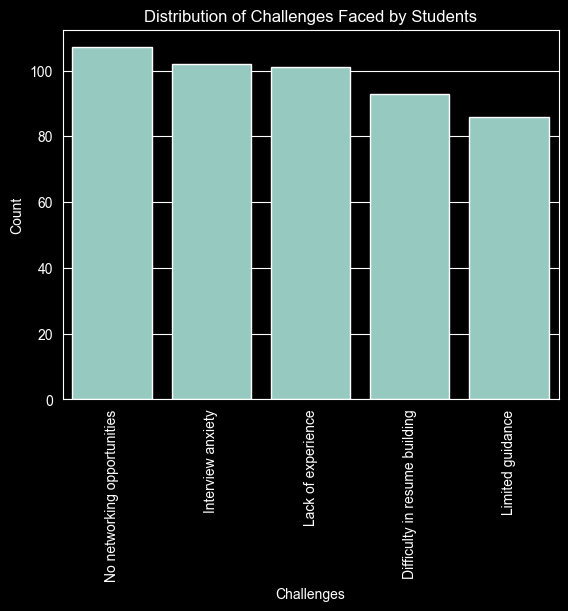

In [36]:
sns.countplot(df,x='challenges',order=df['challenges'].value_counts().sort_values(ascending=False).head().index)
plt.xticks(rotation=90)
plt.title('Distribution of Challenges Faced by Students')
plt.xlabel('Challenges')
plt.ylabel('Count')
plt.show()

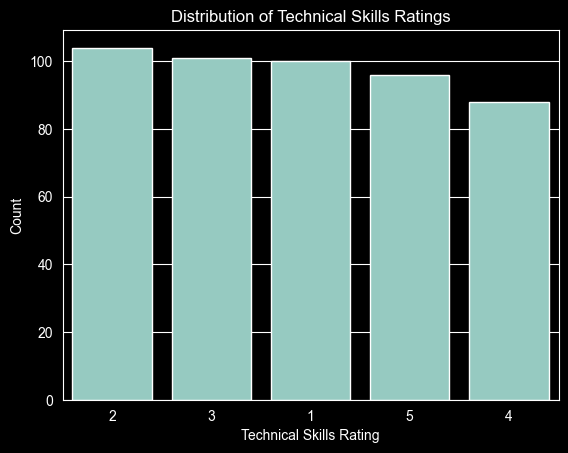

In [37]:
sns.countplot(data=df,x='rating',order=df['rating'].value_counts().sort_values(ascending=False).index)
plt.title('Distribution of Technical Skills Ratings')
plt.xlabel('Technical Skills Rating')
plt.ylabel('Count')
plt.show()

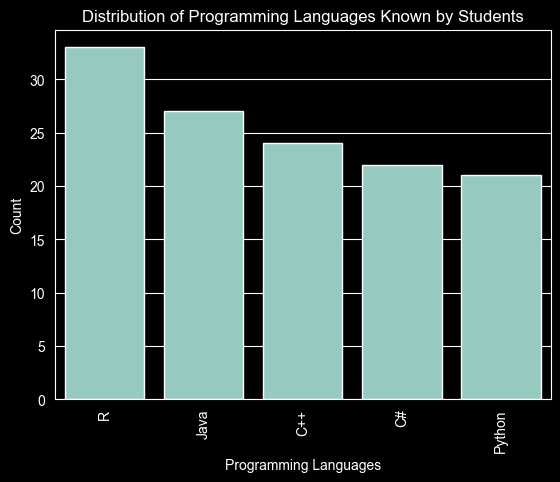

In [38]:
sns.countplot(data=df,x='programming_languages',order=df['programming_languages'].value_counts().sort_values(ascending=False).head().index)
plt.xticks(rotation=90)
plt.title('Distribution of Programming Languages Known by Students')
plt.xlabel('Programming Languages')
plt.ylabel('Count')
plt.show()

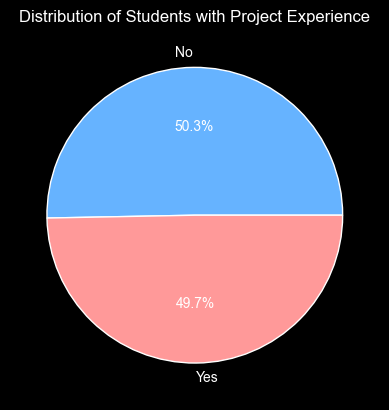

In [39]:
plt.pie(df['projects'].value_counts(), labels=df['projects'].value_counts().index, autopct='%1.1f%%',colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Students with Project Experience')

plt.show()

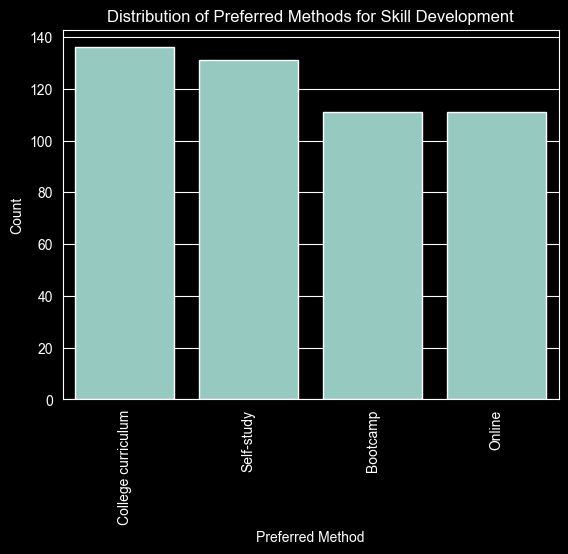

In [40]:
sns.countplot(data=df,x='method',order=df['method'].value_counts().sort_values(ascending=False).index)
plt.xticks(rotation=90)
plt.title('Distribution of Preferred Methods for Skill Development')
plt.xlabel('Preferred Method')
plt.ylabel('Count')
plt.show()

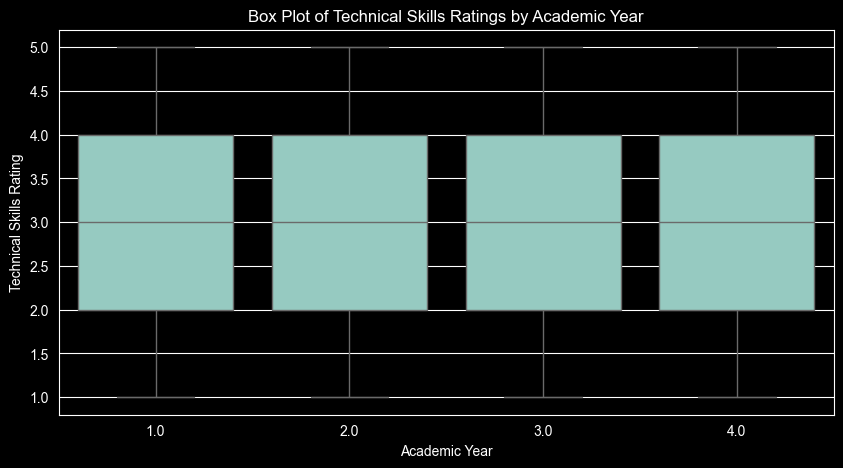

In [41]:
plt.figure(figsize = (10,5))
sns.boxplot(data=df, x='year', y='rating')
plt.title('Box Plot of Technical Skills Ratings by Academic Year')
plt.xlabel('Academic Year')
plt.ylabel('Technical Skills Rating')
plt.show()

In [42]:
! pip install streamlit plotly

In [49]:
df.to_csv('data.csv', index=False)